<a href="https://colab.research.google.com/github/khalishaura/coba1/blob/main/Estimasi_RUL_Exponential_Degradation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import packages
import numpy as np, matplotlib.pyplot as plt, pandas as pd
import scipy.io
import glob
from scipy.stats import kurtosis, skew, spearmanr
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.optimize import fsolve

#File paths
Filenames = glob.glob(r"C:\Users\K9Lima\Downloads\WindTurbine (1)\WindTurbine\data-2013*.mat")

In [ ]:
# Ekstraksi Fitur
def time_domain_features(vib_data):
    N = len(vib_data)
    mean = np.mean(vib_data)
    std = np.std(vib_data)
    rms = np.sqrt(np.mean(vib_data**2))
    peak = np.max(np.abs(vib_data))
    peak2peak = np.max(vib_data) - np.min(vib_data)
    skewness = skew(vib_data)
    kurt = kurtosis(vib_data, fisher=False)
    shape_factor = rms / np.mean(np.abs(vib_data))
    crest_factor = peak / rms
    impulse_factor = peak / np.mean(np.abs(vib_data))
    margin_factor = peak / (np.mean(np.sqrt(np.abs(vib_data)))**2)

    features = np.array([
        mean, std, rms, peak, peak2peak, skewness,
        kurt, shape_factor, crest_factor, impulse_factor, margin_factor
    ])
    return features

In [ ]:
N_features = 11
N_days = len(Filenames)

features50days = np.zeros((N_days, N_features))
for i in range(N_days):
    matlab_data = scipy.io.loadmat(Filenames[i], struct_as_record=False)
    vib_data = matlab_data['vibration'][:,0]
    features50days[i,:] = time_domain_features(vib_data)


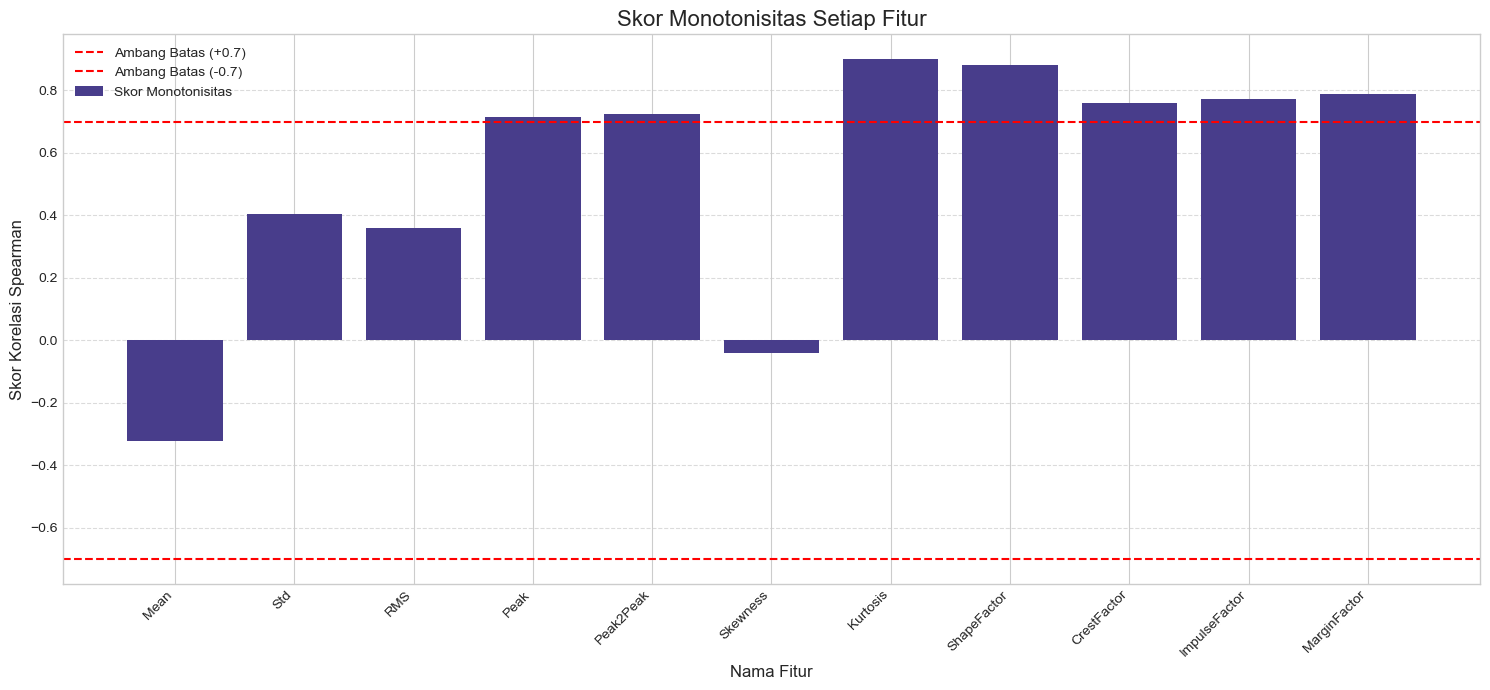

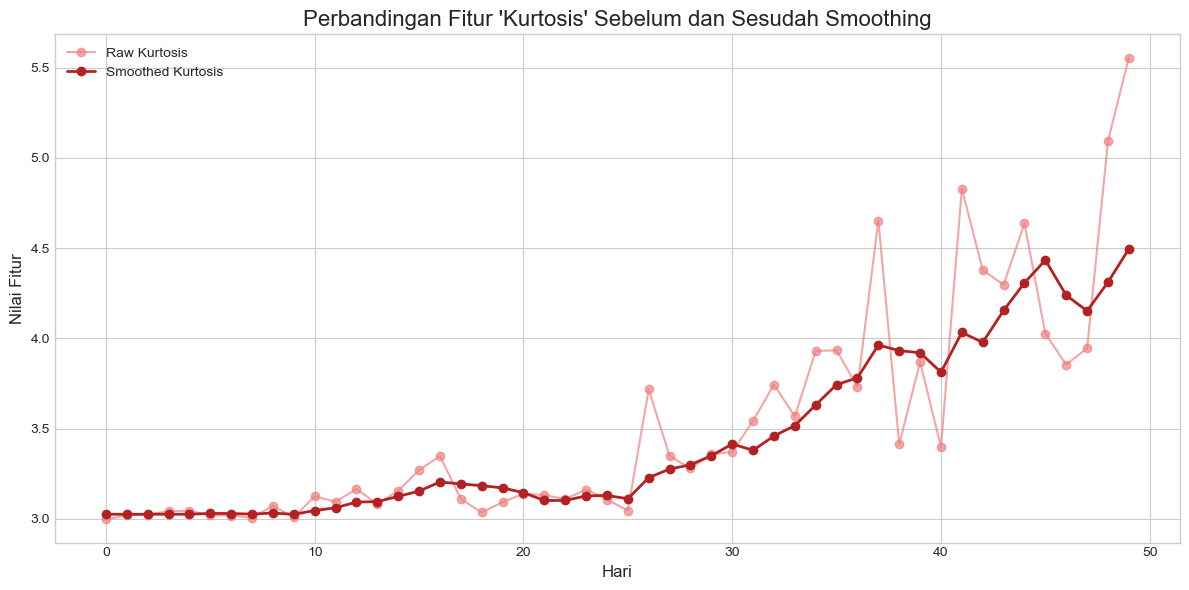

Fitur dengan monotonisitas >= 0.7: ['Peak' 'Peak2Peak' 'Kurtosis' 'ShapeFactor' 'CrestFactor' 'ImpulseFactor'
 'MarginFactor']


In [ ]:
#Smoothing Feature
windowSize = 5
features50days_smoothed = pd.DataFrame(features50days).rolling(window=windowSize, min_periods=1).mean().values

#Ganti nilai NaN
features50days_smoothed[:windowSize-1, :] = features50days_smoothed[windowSize-1, :]

#Hitung monotonisitas SETELAH smoothing, pada data 32 hari pertama
Ndays_train = 32
features_train = features50days_smoothed[:Ndays_train, :]

# Define features_train_smoothed as the smoothed training features
features_train_smoothed = features_train

feature_monotonicity = np.zeros((N_features,))
for feature in range(N_features):
        result = spearmanr(range(Ndays_train), features_train_smoothed[:,feature])
        feature_monotonicity[feature] = result.statistic

#Plot monotonisitas
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 7))
plt.bar(features_Names, feature_monotonicity, color='darkslateblue', label='Skor Monotonisitas')
plt.axhline(y=0.7, color='r', linestyle='--', label='Ambang Batas (+0.7)')
plt.axhline(y=-0.7, color='r', linestyle='--', label='Ambang Batas (-0.7)')
plt.title("Skor Monotonisitas Setiap Fitur", fontsize=16)
plt.ylabel("Skor Korelasi Spearman", fontsize=12)
plt.xlabel("Nama Fitur", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Sekarang kita bisa mencari fitur terbaik dan membuat plot perbandingannya.
best_feature_idx = np.argmax(np.abs(feature_monotonicity))
best_feature_name = features_Names[best_feature_idx]

plt.figure(figsize=(12, 6))
plt.plot(range(N_days), features50days[:, best_feature_idx], 'o-', color='lightcoral', alpha=0.7, label=f'Raw {best_feature_name}')
plt.plot(range(N_days), features50days_smoothed[:, best_feature_idx], 'o-', color='firebrick', linewidth=2, label=f'Smoothed {best_feature_name}')
plt.title(f"Perbandingan Fitur '{best_feature_name}' Sebelum dan Sesudah Smoothing", fontsize=16)
plt.xlabel("Hari", fontsize=12)
plt.ylabel("Nilai Fitur", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Seleksi fitur berdasarkan monotonicity
selected_features = np.where(np.abs(feature_monotonicity) > 0.7)[0]

features_Names = np.array(['Mean', 'Std', 'RMS', 'Peak', 'Peak2Peak', 'Skewness', 'Kurtosis', 'ShapeFactor',
                    'CrestFactor', 'ImpulseFactor', 'MarginFactor'])
print(f"Fitur dengan monotonisitas >= 0.7: {features_Names[selected_features]}")
selectFeatures_train = features_train_smoothed[:, selected_features]

In [ ]:
# Pilih fitur yang sama untuk seluruh data (bukan hanya training)
selectFeatures_all = features50days_smoothed[:, selected_features]

# Normalisasi data
scaler = StandardScaler().fit(selectFeatures_train)
selectFeatures_train_normal = scaler.transform(selectFeatures_train)
selectFeatures_all_normal = scaler.transform(selectFeatures_all)

   # Latih PCA hanya pada data training
pca = PCA(n_components=1).fit(selectFeatures_train_normal)

# Transformasi semua data untuk mendapatkan HI
PCA_all_scores = pca.transform(selectFeatures_all_normal)
HI_all = PCA_all_scores[:, 0]

    # Pastikan tren HI meningkat (jika tidak, balikkan tandanya)
    # Ini untuk konsistensi, agar HI selalu menunjukkan degradasi yang meningkat
if spearmanr(range(N_days), HI_all).correlation < 0:
    HI_all = -HI_all

# Definisikan model eksponensial sederhana (tanpa offset 'c')
def exponential_model_simple(t, a, b):
    return a * np.exp(b * t)

    # Siapkan data training untuk HI
HI_train = HI_all[:Ndays_train]

    # Normalisasi HI training agar dimulai dari 0 (sesuai referensi)
HI_train_normalized = HI_train - HI_train[0]

    # Lakukan fitting model pada data HI yang sudah dinormalisasi
params_opt, _ = curve_fit(exponential_model_simple, range(Ndays_train), HI_train_normalized)
a, b = params_opt

In [ ]:
# Prediksi RUL
failure_threshold = HI_all[-1] - HI_all[0]

# Buat fungsi untuk diselesaikan dengan fsolve
def equation_to_solve(t):
    return exponential_model_simple(t, a, b) - failure_threshold

# Gunakan fsolve untuk mencari waktu kegagalan (TTF)
# tebakan awal diatur ke 40 hari
predicted_ttf = fsolve(equation_to_solve, x0=40)[0]

# Hitung RUL dari hari terakhir training
predicted_rul = predicted_ttf - Ndays_train

print("\n--- Estimasi RUL ---")
print(f"Failure Threshold (Normalisasi) ditetapkan pada: {failure_threshold:.4f}")
print(f"Prediksi Waktu Kegagalan (TTF) dari data {Ndays_train} hari: Hari ke-{predicted_ttf:.2f}")
print(f"Estimasi RUL dari hari ke-{Ndays_train}: {predicted_rul:.2f} hari")



--- Estimasi RUL ---
Failure Threshold (Normalisasi) ditetapkan pada: 23.6597
Prediksi Waktu Kegagalan (TTF) dari data 32 hari: Hari ke-44.12
Estimasi RUL dari hari ke-32: 12.12 hari


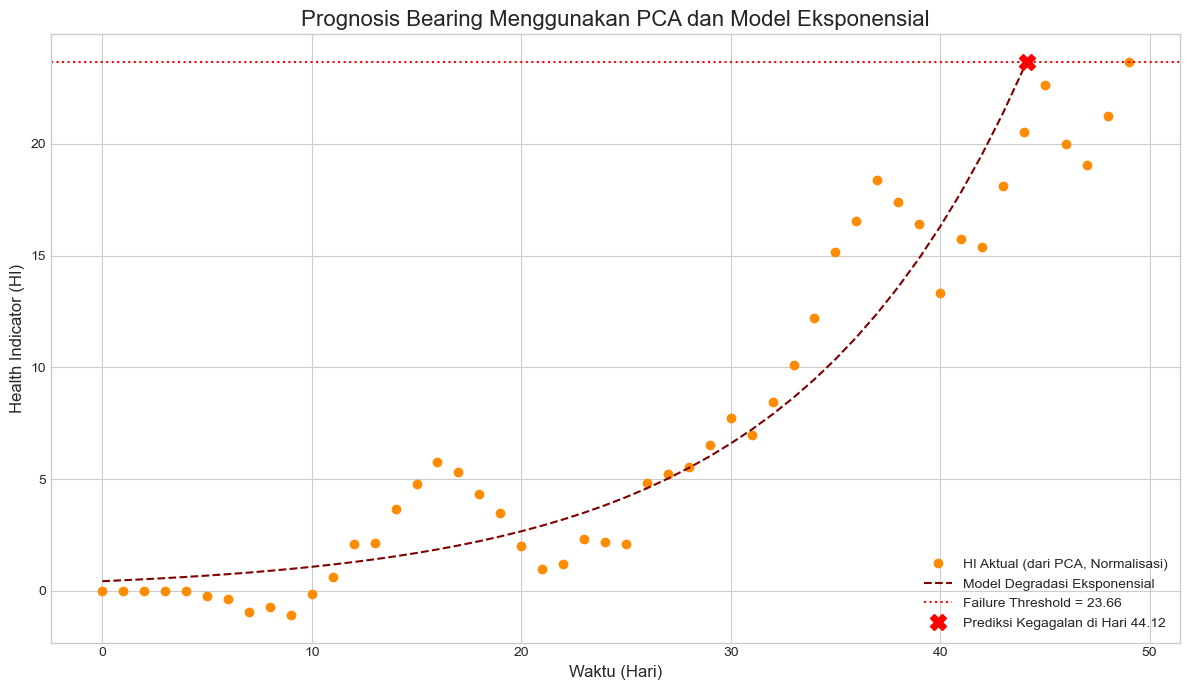

In [ ]:
# --- LANGKAH G: VISUALISASI ---plt.style.use('seaborn-v0_8-whitegrid'))
fig, ax = plt.subplots(figsize=(12, 7))
# Plot HI aktual yang sudah dinormalisasi
t_full = np.arange(N_days)
HI_all_normalized = HI_all - HI_all[0]
ax.plot(t_full, HI_all_normalized, 'o', color='darkorange', label='HI Aktual (dari PCA, Normalisasi)')

    # Plot model yang diprediksi
t_model = np.arange(int(predicted_ttf) + 1)
HI_predicted = exponential_model_simple(t_model, a, b)
ax.plot(t_model, HI_predicted, '--', color='maroon', label='Model Degradasi Eksponensial')

    # Plot garis Failure Threshold
ax.axhline(y=failure_threshold, color='red', linestyle=':', label=f'Failure Threshold = {failure_threshold:.2f}')

    # Tandai titik prediksi kegagalan
ax.plot(predicted_ttf, failure_threshold, 'X', color='red', markersize=12, label=f'Prediksi Kegagalan di Hari {predicted_ttf:.2f}')

ax.set_title('Prognosis Bearing Menggunakan PCA dan Model Eksponensial', fontsize=16)
ax.set_xlabel('Waktu (Hari)', fontsize=12)
ax.set_ylabel('Health Indicator (HI)', fontsize=12)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
